# 🧬 Chin Structure Analysis — Dual Photo Mode
**AI Face Analysis Project — Task 1**

Two photos are required for complete chin analysis:

| Photo | Metrics analysed |
|-------|------------------|
| **📸 Frontal** | Alignment · Width · Height · Jaw Shape · Symmetry |
| **📷 Side Profile (45-60° Semi-Profile)** | Forward Projection · Nasomental Angle · Chin-Lip · Profile Convexity |

In [90]:
print('All packages are installed in the Face Analysis (venv) environment!')


All packages are installed in the Face Analysis (venv) environment!


In [91]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math, json, warnings
warnings.filterwarnings('ignore')


print(f'MediaPipe {mp.__version__} | OpenCV {cv2.__version__}')

MediaPipe 0.10.35 | OpenCV 5.0.0


## 🗺️ Landmark Index Reference

In [92]:
# MediaPipe Face Mesh landmark indices used in this analysis
LM = {
    # ── FRONTAL ──────────────────────────────────────────────────────────
    'chin_tip'           : 152,   # Pogonion
    'chin_left'          : 176,   # Chin base left
    'chin_right'         : 400,   # Chin base right
    'chin_wide_left'     : 150,
    'chin_wide_right'    : 379,
    'jaw_corner_left'    : 172,   # Left gonion
    'jaw_corner_right'   : 397,   # Right gonion
    'jaw_angle_left'     : 136,   # Left mandibular angle
    'jaw_angle_right'    : 365,   # Right mandibular angle
    'left_cheekbone'     : 234,
    'right_cheekbone'    : 454,
    'mouth_left'         : 61,
    'mouth_right'        : 291,
    'lower_lip_bottom'   : 17,
    'forehead_top'       : 10,
    'glabella'           : 9,
    'nose_tip'           : 1,
    # ── PROFILE ──────────────────────────────────────────────────────────
    'p_forehead'         : 10,
    'p_glabella'         : 9,    # Nasion
    'p_nose_tip'         : 1,    # Pronasale
    'p_nose_base'        : 2,    # Subnasale
    'p_upper_lip'        : 0,    # Labrale superius
    'p_lower_lip'        : 17,   # Labrale inferius
    'p_chin_tip'         : 152,  # Pogonion
    'p_jaw_angle'        : 172,  # Visible-side gonion
}
print('Landmark indices defined!')

Landmark indices defined!


## 🔧 Utility Functions

In [93]:
import urllib.request
import os
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download model if not exists
MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading Face Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)

def pt(lm, idx, w, h):
    l = lm[idx]
    return (int(l.x * w), int(l.y * h))

def dist(p1, p2):
    import math
    return math.hypot(p2[0]-p1[0], p2[1]-p1[1])

def angle_3pts(p1, p2, p3):
    import math
    a = math.hypot(p1[0]-p2[0], p1[1]-p2[1])
    b = math.hypot(p1[0]-p3[0], p1[1]-p3[1])
    c = math.hypot(p3[0]-p2[0], p3[1]-p2[1])
    if a * c == 0: return 0
    val = (a*a + c*c - b*b) / (2 * a * c)
    val = max(-1.0, min(1.0, val))
    return math.degrees(math.acos(val))

def extract_landmarks(image_path, label=""):
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Could not read {image_path}")
    h, w, _ = img.shape
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.FaceLandmarkerOptions(base_options=base_options,
                                           output_face_blendshapes=False,
                                           output_facial_transformation_matrixes=False,
                                           num_faces=1,
                                           min_face_detection_confidence=0.1,
                                           min_face_presence_confidence=0.1)
    
    with vision.FaceLandmarker.create_from_options(options) as detector:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        detection_result = detector.detect(mp_image)
        if not detection_result.face_landmarks:
            raise ValueError(f"\n\n❌ NO FACE DETECTED in {label} photo! \nMediaPipe requires both eyes to be at least slightly visible. \n\U0001f4a1 FIX: Please use a 45-degree to 60-degree semi-profile photo instead of a strict 90-degree profile.\n")
        return detection_result.face_landmarks[0], img, rgb, h, w


## 📸 Frontal Photo — Analysis Functions
*(Alignment · Width · Height · Jaw Shape · Symmetry)*

In [94]:
# ── Chin Alignment ────────────────────────────────────────────────────────
def frontal_alignment(lm, w, h):
    chin   = pt(lm, LM['chin_tip'], w, h)
    lc     = pt(lm, LM['left_cheekbone'], w, h)
    rc     = pt(lm, LM['right_cheekbone'], w, h)
    mid_x  = (lc[0] + rc[0]) / 2
    fw     = dist(lc, rc)
    dev    = chin[0] - mid_x
    devp   = abs(dev) / fw * 100
    if   devp < 2:  r, s = 'CENTRALLY ALIGNED', 100
    elif devp < 4:  r, s = ('SLIGHTLY DEVIATED ' + ('LEFT' if dev<0 else 'RIGHT')), 80
    elif devp < 7:  r, s = ('MODERATELY DEVIATED ' + ('LEFT' if dev<0 else 'RIGHT')), 60
    else:            r, s = ('SIGNIFICANTLY DEVIATED ' + ('LEFT' if dev<0 else 'RIGHT')), 30
    return {'metric':'Chin Alignment','result':r,'score':s,
            'deviation_pct':round(devp,2),'chin_tip':chin,'midline_x':mid_x}

# ── Chin Width ────────────────────────────────────────────────────────────
def frontal_width(lm, w, h):
    cl = pt(lm, LM['chin_left'], w, h);   cr = pt(lm, LM['chin_right'], w, h)
    ml = pt(lm, LM['mouth_left'], w, h);  mr = pt(lm, LM['mouth_right'], w, h)
    lc = pt(lm, LM['left_cheekbone'], w, h); rc = pt(lm, LM['right_cheekbone'], w, h)
    cw = dist(cl,cr);  mw = dist(ml,mr);  fw = dist(lc,rc)
    rat = cw / mw
    if   0.90<=rat<=1.10: r,s = 'ADEQUATE / IDEAL', 100
    elif 0.80<=rat< 0.90: r,s = 'SLIGHTLY NARROW', 75
    elif rat <  0.80:     r,s = 'NARROW', 50
    elif 1.10< rat<=1.25: r,s = 'BROAD', 75
    else:                  r,s = 'VERY BROAD', 50
    return {'metric':'Chin Width (Breadth)','result':r,'score':s,
            'chin_to_mouth_ratio':round(rat,3),'chin_to_face_ratio':round(cw/fw,3),
            'chin_width_px':round(cw,1),'chin_left':cl,'chin_right':cr}

# ── Chin Height ───────────────────────────────────────────────────────────
def frontal_height(lm, w, h):
    fhd = pt(lm, LM['forehead_top'], w, h)
    chi = pt(lm, LM['chin_tip'], w, h)
    llb = pt(lm, LM['lower_lip_bottom'], w, h)
    nst = pt(lm, LM['nose_tip'], w, h)
    fh  = dist(fhd, chi);  l3  = dist(nst, chi)
    rat = l3 / fh
    if   0.28<=rat<=0.38: r,s = 'ADEQUATE HEIGHT', 100
    elif rat < 0.28:       r,s = 'SHORT LOWER THIRD', 60
    else:                   r,s = 'LONG LOWER THIRD', 60
    return {'metric':'Chin Height','result':r,'score':s,
            'lower_third_ratio':round(rat,3),'chin_tip':chi,
            'lower_lip_bottom':llb,'forehead_top':fhd}

# ── Jaw Shape ─────────────────────────────────────────────────────────────
def frontal_jaw_shape(lm, w, h):
    cl  = pt(lm, LM['chin_left'], w, h);   cr  = pt(lm, LM['chin_right'], w, h)
    jal = pt(lm, LM['jaw_angle_left'], w, h); jar = pt(lm, LM['jaw_angle_right'], w, h)
    jcl = pt(lm, LM['jaw_corner_left'], w, h); jcr = pt(lm, LM['jaw_corner_right'], w, h)
    tap = dist(cl, cr) / dist(jal, jar)
    if   tap > 0.80: r,d,s = 'SQUARE JAW',   'Chin~jaw-angle width — square jaw.', 75
    elif tap >= 0.60: r,d,s = 'U-SHAPED JAW', 'Moderate taper — rounded U-shape (ideal).', 100
    else:              r,d,s = 'V-SHAPED JAW', 'Strong taper — pointed V-shape jaw.', 75
    return {'metric':'Jaw Shape','result':r,'score':s,'description':d,
            'taper_ratio':round(tap,3),'jaw_left':jcl,'jaw_right':jcr,
            'chin_left':cl,'chin_right':cr}

# ── Chin Symmetry ─────────────────────────────────────────────────────────
def frontal_symmetry(lm, w, h):
    ct  = pt(lm, LM['chin_tip'], w, h)
    jl  = pt(lm, LM['jaw_corner_left'], w, h)
    jr  = pt(lm, LM['jaw_corner_right'], w, h)
    ld = dist(ct,jl);  rd = dist(ct,jr)
    asy = abs(ld-rd) / max(ld,rd) * 100
    if   asy < 3:  r,s = 'HIGHLY SYMMETRIC', 100
    elif asy < 6:  r,s = 'MILDLY ASYMMETRIC', 80
    elif asy < 10: r,s = 'MODERATELY ASYMMETRIC', 60
    else:           r,s = 'SIGNIFICANTLY ASYMMETRIC', 30
    return {'metric':'Chin Symmetry','result':r,'score':s,'asymmetry_pct':round(asy,2)}

print('Frontal analysis functions ready!')

Frontal analysis functions ready!


## 📷 Side Profile Photo — Analysis Functions
*(Forward Projection · Nasomental Angle · Chin-Lip · Profile Convexity)*

In [95]:
# ── Forward Projection (TRUE, from profile) ──────────────────────────────
def profile_forward_projection(lm, w, h):
    """
    Ricketts E-plane: line nose tip -> chin tip.
    Measures lip position and chin offset vs nasion vertical.
    """
    def signed_dist_to_line(px, py, ax, ay, bx, by):
        dx,dy = bx-ax, by-ay
        L = math.sqrt(dx**2+dy**2)
        return ((px-ax)*dy - (py-ay)*dx) / L if L else 0

    nasion   = pt(lm, LM['p_glabella'],  w, h)
    nose_tip = pt(lm, LM['p_nose_tip'],  w, h)
    chin_tip = pt(lm, LM['p_chin_tip'],  w, h)
    lo_lip   = pt(lm, LM['p_lower_lip'], w, h)
    up_lip   = pt(lm, LM['p_upper_lip'], w, h)
    forehead = pt(lm, LM['p_forehead'],  w, h)

    # E-plane signed distance of lower lip
    e_dist = signed_dist_to_line(
        lo_lip[0], lo_lip[1],
        nose_tip[0], nose_tip[1],
        chin_tip[0], chin_tip[1])

    # Chin horizontal offset vs nasion vertical (profile depth axis)
    fh    = dist(forehead, chin_tip)
    c_off = chin_tip[0] - nasion[0]
    ratio = c_off / fh

    if   -0.05 <= ratio <= 0.08: r,s = 'IDEAL PROJECTION', 100
    elif ratio > 0.08:            r,s = 'FORWARD / PROMINENT CHIN', 80
    elif -0.15 <= ratio < -0.05: r,s = 'MILDLY RECESSED CHIN', 70
    else:                          r,s = 'SIGNIFICANTLY RECESSED CHIN', 40

    return {'metric':'Forward Projection (Profile)','result':r,'score':s,
            'proj_ratio':round(ratio,3),'e_plane_dist_px':round(e_dist,1),
            'nose_tip':nose_tip,'chin_tip':chin_tip,'nasion':nasion,
            'lower_lip':lo_lip,'upper_lip':up_lip}

# ── Nasomental Angle ─────────────────────────────────────────────────────
def profile_nasomental_angle(lm, w, h):
    """
    Angle: nose_tip -- nose_base -- chin_tip.
    Ideal: 120-135 degrees.
    """
    nt = pt(lm, LM['p_nose_tip'],  w, h)
    nb = pt(lm, LM['p_nose_base'], w, h)
    ct = pt(lm, LM['p_chin_tip'],  w, h)
    ang = angle_3pts(nt, nb, ct)
    if   120 <= ang <= 135: r,s = 'IDEAL NASOMENTAL ANGLE', 100
    elif 110 <= ang < 120:  r,s = 'SLIGHTLY ACUTE — chin prominent', 75
    elif ang < 110:          r,s = 'ACUTE — PROMINENT CHIN', 60
    elif 135 < ang <= 150:  r,s = 'OBTUSE — RETRUDED CHIN', 70
    else:                    r,s = 'SEVERELY OBTUSE — WEAK CHIN', 40
    return {'metric':'Nasomental Angle (Profile)','result':r,'score':s,
            'angle_deg':round(ang,1),'nose_tip':nt,'nose_base':nb,'chin_tip':ct}

# ── Chin-Lip Relationship ─────────────────────────────────────────────────
def profile_chin_lip(lm, w, h):
    """
    Horizontal and vertical relationship of lower lip to chin tip.
    h_ratio > 0 = lip in front of chin; ideal near 0.
    """
    lo_lip  = pt(lm, LM['p_lower_lip'], w, h)
    chin    = pt(lm, LM['p_chin_tip'],  w, h)
    forehead= pt(lm, LM['p_forehead'],  w, h)
    fh = dist(forehead, chin)
    h_ratio = (lo_lip[0] - chin[0]) / fh
    v_ratio = (chin[1]   - lo_lip[1]) / fh
    if   h_ratio > 0.02:  r,s = 'LIP ANTERIOR TO CHIN (lip prominent)', 70
    elif h_ratio >= -0.02: r,s = 'BALANCED LIP-CHIN RELATION', 100
    else:                   r,s = 'CHIN ANTERIOR TO LIP (chin prominent)', 75
    return {'metric':'Chin-Lip Relationship (Profile)','result':r,'score':s,
            'horizontal_ratio':round(h_ratio,3),'vertical_ratio':round(v_ratio,3),
            'lower_lip':lo_lip,'chin_tip':chin}

# ── Facial Profile Convexity ──────────────────────────────────────────────
def profile_convexity(lm, w, h):
    """
    Profile angle: glabella -- subnasale -- pogonion.
    Ideal straight profile = 165-175 degrees.
    """
    glab = pt(lm, LM['p_glabella'],  w, h)
    nb   = pt(lm, LM['p_nose_base'], w, h)
    chin = pt(lm, LM['p_chin_tip'],  w, h)
    ang  = angle_3pts(glab, nb, chin)
    if   165 <= ang <= 175: r,s = 'STRAIGHT PROFILE (ideal)', 100
    elif 155 <= ang < 165:  r,s = 'MILDLY CONVEX (weak chin)', 75
    elif ang < 155:          r,s = 'CONVEX PROFILE (retruded chin)', 50
    elif ang > 175:          r,s = 'CONCAVE PROFILE (prognathic chin)', 65
    else:                    r,s = 'PROFILE NORMAL', 100
    return {'metric':'Facial Profile Convexity','result':r,'score':s,
            'profile_angle_deg':round(ang,1),'glabella':glab,'nose_base':nb,'chin_tip':chin}

print('Profile analysis functions ready!')

Profile analysis functions ready!


## 🎨 Visualization Functions

In [96]:
def _get_scale(img):
    # Base scale 1.0 for an 800px high image
    return max(1.0, img.shape[0] / 800.0)

def _dot(img, p, c=(0,255,100), r=5):
    # Scale radius
    scaled_r = int(r * _get_scale(img) * 1.5)
    cv2.circle(img, p, scaled_r, c, -1)
    cv2.circle(img, p, scaled_r+2, (255,255,255), max(1, int(1.5 * _get_scale(img))))

def _line(img, p1, p2, c=(0,200,255), t=2):
    scaled_t = max(2, int(t * _get_scale(img) * 1.2))
    cv2.line(img, p1, p2, c, scaled_t, cv2.LINE_AA)

def _lbl(img, p, txt, c=(255,255,255), off=(6,-10)):
    scale = _get_scale(img) * 1.5 # Overall boost
    scaled_off = (int(off[0] * scale * 1.5), int(off[1] * scale * 1.5))
    pos = (p[0]+scaled_off[0], p[1]+scaled_off[1])
    # Boost font size considerably
    font_scale = max(0.6, 0.5 * scale)
    thick = max(1, int(1.5 * scale))
    cv2.putText(img,txt,pos,cv2.FONT_HERSHEY_SIMPLEX,font_scale,(0,0,0),thick+3,cv2.LINE_AA)
    cv2.putText(img,txt,pos,cv2.FONT_HERSHEY_SIMPLEX,font_scale,c,thick,cv2.LINE_AA)


def _draw_legend(img, entries):
    import cv2
    import numpy as np
    h, w = img.shape[:2]
    scale = _get_scale(img)
    font_scale = max(0.5, 0.45 * scale)
    thick = max(1, int(1.5 * scale))
    line_spacing = int(35 * scale)
    margin = int(20 * scale)
    
    # Calculate box size dynamically based on text length
    max_text_len = max([len(t) for t, c in entries])
    box_w = int((max_text_len * 12 + 60) * scale)
    box_h = len(entries) * line_spacing + margin
    
    # Create padded image to prevent overlap
    pad_h = box_h + margin * 2
    new_img = np.zeros((h + pad_h, w, 3), dtype=np.uint8)
    new_img[:h, :] = img
    
    # Bottom right coordinates in the padded area
    x1 = w - box_w - margin
    y1 = h + margin
    x2 = w - margin
    y2 = y1 + box_h
    
    # Draw legend box
    cv2.rectangle(new_img, (x1, y1), (x2, y2), (30,30,30), -1)
    cv2.rectangle(new_img, (x1, y1), (x2, y2), (255,255,255), max(1, int(1 * scale)))
    
    # Draw text and colored lines
    text_x = x1 + int(15 * scale)
    text_y = y1 + int(30 * scale)
    
    for text, color in entries:
        line_start = (text_x, text_y - int(5 * scale))
        line_end = (text_x + int(30 * scale), text_y - int(5 * scale))
        cv2.line(new_img, line_start, line_end, color, max(2, int(4 * scale)), cv2.LINE_AA)
        
        txt_pos = (text_x + int(45 * scale), text_y)
        cv2.putText(new_img, text, txt_pos, cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thick+2, cv2.LINE_AA)
        cv2.putText(new_img, text, txt_pos, cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255,255,255), thick, cv2.LINE_AA)
        text_y += line_spacing
        
    return new_img

def draw_frontal(img_rgb, res):
    img = img_rgb.copy()
    al = res['alignment'];  wd = res['width']
    ht = res['height'];     sh = res['jaw_shape']

    # Face midline
    mx = int(al['midline_x']);  h_img = img.shape[0]
    _line(img,(mx,0),(mx,h_img),(255,255,0),1)

    # Chin tip + alignment arrow
    ct = al['chin_tip']
    _dot(img, ct, (0,60,255), 7)
    import cv2
    cv2.arrowedLine(img,(mx,ct[1]),(ct[0],ct[1]),(255,140,0),max(2, int(2*_get_scale(img))),cv2.LINE_AA,tipLength=0.25)

    # Chin width
    cl,cr = wd['chin_left'], wd['chin_right']
    _dot(img,cl,(0,220,80));  _dot(img,cr,(0,220,80))
    _line(img,cl,cr,(0,220,80))

    # Jaw shape
    jl,jr = sh['jaw_left'], sh['jaw_right']
    _dot(img,jl,(200,80,255));  _dot(img,jr,(200,80,255))
    _line(img,jl,cl,(200,80,255));  _line(img,jr,cr,(200,80,255))
    _line(img,jl,jr,(200,80,255))

    # Chin height (lip-to-chin)
    llb = ht['lower_lip_bottom']
    _dot(img,llb,(100,180,255))
    _line(img,llb,ct,(100,180,255))

    # Draw Legend
    entries = [
        ("Midline", (255,255,0)),
        ("Chin Tip / Alignment", (0,60,255)),
        (f"Chin Width: {wd['chin_width_px']}px", (0,220,80)),
        ("Jaw Shape", (200,80,255)),
        ("Chin Height", (100,180,255))
    ]
    return _draw_legend(img, entries)

def draw_profile(img_rgb, res):
    img = img_rgb.copy()
    fp = res['forward_projection']
    nm = res['nasomental']
    cl = res['chin_lip']
    cv = res['convexity']

    nt = fp['nose_tip'];  ct = fp['chin_tip']
    ll = fp['lower_lip']; nas = fp['nasion']

    # Ricketts E-plane: nose tip -> chin tip
    _line(img, nt, ct, (255,200,0), 2)
    _dot(img, nt, (255,200,0), 6)

    # Chin tip
    _dot(img, ct, (0,60,255), 7)

    # Lower lip on E-plane
    _dot(img, ll, (0,220,180), 5)
    _line(img, ll, nt, (100,100,200), 1)

    # Nasion vertical
    ih = img.shape[0]
    _line(img, (nas[0],0), (nas[0],ih), (255,255,100), 1)

    # Nasomental angle
    nb = nm['nose_base']
    _dot(img, nb, (200,100,255), 5)
    _line(img, nt, nb, (200,100,255), 1)
    _line(img, nb, ct, (200,100,255), 1)

    # Profile convexity line
    glab = cv['glabella']
    _dot(img, glab, (255,120,0), 5)
    _line(img, glab, nb, (255,120,0), 1)

    # Draw Legend
    entries = [
        ("E-Plane", (255,200,0)),
        ("Chin Tip", (0,60,255)),
        ("Lower Lip", (0,220,180)),
        ("Nasion Vert", (255,255,100)),
        (f"Nasomental Ang: {nm['angle_deg']} deg", (200,100,255)),
        ("Profile Convexity", (255,120,0))
    ]
    return _draw_legend(img, entries)


## 🚀 Run Analysis
> **👇 Run this cell to open a file picker and select your images!**

In [97]:
# ══════════════════════════════════════════════════════════════
#   SELECT YOUR IMAGE PATHS
# ══════════════════════════════════════════════════════════════
import tkinter as tk
from tkinter import filedialog

def select_image(title):
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    file_path = filedialog.askopenfilename(title=title, filetypes=[('Image files', '*.jpg *.jpeg *.png')])
    root.destroy()
    return file_path

print('Please select the FRONTAL face photo in the popup window...')
FRONTAL_IMAGE = select_image('Select Frontal Photo')
if not FRONTAL_IMAGE: raise ValueError('Frontal image selection cancelled.')

print('Please select the SIDE PROFILE face photo in the popup window...')
PROFILE_IMAGE = select_image('Select Profile Photo')
if not PROFILE_IMAGE: raise ValueError('Profile image selection cancelled.')

print(f'\nSelected Frontal: {FRONTAL_IMAGE}')
print(f'Selected Profile: {PROFILE_IMAGE}\n')
# ══════════════════════════════════════════════════════════════

print('Extracting landmarks from both photos...')

# Frontal
lm_f, bgr_f, rgb_f, h_f, w_f = extract_landmarks(FRONTAL_IMAGE, 'FRONTAL')
frontal_results = {
    'alignment' : frontal_alignment(lm_f, w_f, h_f),
    'width'     : frontal_width(lm_f, w_f, h_f),
    'height'    : frontal_height(lm_f, w_f, h_f),
    'jaw_shape' : frontal_jaw_shape(lm_f, w_f, h_f),
    'symmetry'  : frontal_symmetry(lm_f, w_f, h_f),
}

# Profile
lm_p, bgr_p, rgb_p, h_p, w_p = extract_landmarks(PROFILE_IMAGE, 'PROFILE')
profile_results = {
    'forward_projection' : profile_forward_projection(lm_p, w_p, h_p),
    'nasomental'         : profile_nasomental_angle(lm_p, w_p, h_p),
    'chin_lip'           : profile_chin_lip(lm_p, w_p, h_p),
    'convexity'          : profile_convexity(lm_p, w_p, h_p),
}

print('\n--- FRONTAL ---')
for r in frontal_results.values():
    print(f'  {r["metric"]:30s} -> {r["result"]:42s} score:{r["score"]}')

print('\n--- PROFILE ---')
for r in profile_results.values():
    print(f'  {r["metric"]:30s} -> {r["result"]:42s} score:{r["score"]}')

print('\nAnalysis complete!')


Please select the FRONTAL face photo in the popup window...
Please select the SIDE PROFILE face photo in the popup window...

Selected Frontal: C:/Users/PratikJPatel/Downloads/360_F_276114144_xyAwCmx6IraojhvC2l9cNQEYAx6d28Nq.jpg
Selected Profile: C:/Users/PratikJPatel/Downloads/baf3cc0d-14a6-4e4f-a48b-b52d9a344c9b.png

Extracting landmarks from both photos...

--- FRONTAL ---
  Chin Alignment                 -> CENTRALLY ALIGNED                          score:100
  Chin Width (Breadth)           -> NARROW                                     score:50
  Chin Height                    -> LONG LOWER THIRD                           score:60
  Jaw Shape                      -> V-SHAPED JAW                               score:75
  Chin Symmetry                  -> MILDLY ASYMMETRIC                          score:80

--- PROFILE ---
  Forward Projection (Profile)   -> IDEAL PROJECTION                           score:100
  Nasomental Angle (Profile)     -> OBTUSE — RETRUDED CHIN                

## 📊 Full Detailed Report

In [98]:
def print_report(frontal, profile):
    all_s = [r['score'] for r in list(frontal.values()) + list(profile.values())]
    overall = round(sum(all_s)/len(all_s), 1)

    sep = '='*68
    print('\n' + sep)
    print('       🧬  CHIN STRUCTURE DUAL-PHOTO ANALYSIS REPORT')
    print(sep)

    print('\n📸 FRONTAL PHOTO ANALYSIS')
    print('-'*68)
    for k, r in frontal.items():
        s=r['score'];  bar='\u2588'*(s//10)+'\u2591'*(10-s//10)
        print(f'\n  {r["metric"]}')
        print(f'    Result : {r["result"]}')
        print(f'    Score  : [{bar}] {s}/100')
        if k=='alignment':  print(f'    Deviation from midline: {r["deviation_pct"]}%')
        elif k=='width':    print(f'    Chin/Mouth ratio: {r["chin_to_mouth_ratio"]} (ideal ~1.0)  Chin/Face: {r["chin_to_face_ratio"]}')
        elif k=='height':   print(f'    Lower-third ratio: {r["lower_third_ratio"]} (ideal 0.28–0.38)')
        elif k=='jaw_shape':print(f'    Taper ratio: {r["taper_ratio"]}  ({r["description"]})')
        elif k=='symmetry': print(f'    L/R asymmetry: {r["asymmetry_pct"]}%')

    print('\n📷 SIDE PROFILE PHOTO ANALYSIS')
    print('-'*68)
    for k, r in profile.items():
        s=r['score'];  bar='\u2588'*(s//10)+'\u2591'*(10-s//10)
        print(f'\n  {r["metric"]}')
        print(f'    Result : {r["result"]}')
        print(f'    Score  : [{bar}] {s}/100')
        if k=='forward_projection': print(f'    Proj ratio: {r["proj_ratio"]}  E-plane dist: {r["e_plane_dist_px"]}px')
        elif k=='nasomental':       print(f'    Nasomental angle: {r["angle_deg"]}°  (ideal 120–135°)')
        elif k=='chin_lip':         print(f'    H-ratio: {r["horizontal_ratio"]}  V-ratio: {r["vertical_ratio"]} (0=balanced)')
        elif k=='convexity':        print(f'    Profile angle: {r["profile_angle_deg"]}°  (ideal 165–175°)')

    bar_ov = '\u2588'*int(overall//10)+'\u2591'*(10-int(overall//10))
    print('\n'+'-'*68)
    print(f'  \U0001f3c6 OVERALL CHIN SCORE: [{bar_ov}] {overall}/100')
    print(sep)

    print('\n  \U0001f4a1 RECOMMENDATIONS:')
    recs=[]
    if frontal['alignment']['score']<80:   recs.append('[FRONTAL] Chin deviation — evaluate filler/correction.')
    if frontal['width']['result'] in ['NARROW','SLIGHTLY NARROW']: recs.append('[FRONTAL] Narrow chin — base-width filler may help.')
    if frontal['width']['result'] in ['BROAD','VERY BROAD']:       recs.append('[FRONTAL] Broad chin — evaluate nose/chin harmony.')
    if frontal['height']['result']=='SHORT LOWER THIRD':           recs.append('[FRONTAL] Short lower face — chin height augmentation.')
    if frontal['height']['result']=='LONG LOWER THIRD':            recs.append('[FRONTAL] Long lower face — evaluate bite relationship.')
    if frontal['symmetry']['score']<80:    recs.append('[FRONTAL] Asymmetry — asymmetric filler placement.')
    fp=profile['forward_projection']
    if 'RECESSED' in fp['result']:         recs.append('[PROFILE] Recessed chin confirmed — chin filler/implant recommended.')
    if 'PROMINENT' in fp['result']:        recs.append('[PROFILE] Prominent chin — evaluate with lip projection.')
    if profile['nasomental']['score']<80:  recs.append(f'[PROFILE] Nasomental angle {profile["nasomental"]["angle_deg"]}° outside ideal 120-135°.')
    if profile['convexity']['score']<80:   recs.append(f'[PROFILE] {profile["convexity"]["result"]} — consider orthognathic evaluation.')
    if not recs:
        print('  \u2705 Chin structure is well-balanced across both views!')
    for r in recs:
        print(f'  \u2192 {r}')
    print(sep+'\n')

print_report(frontal_results, profile_results)


       🧬  CHIN STRUCTURE DUAL-PHOTO ANALYSIS REPORT

📸 FRONTAL PHOTO ANALYSIS
--------------------------------------------------------------------

  Chin Alignment
    Result : CENTRALLY ALIGNED
    Score  : [██████████] 100/100
    Deviation from midline: 0.94%

  Chin Width (Breadth)
    Result : NARROW
    Score  : [█████░░░░░] 50/100
    Chin/Mouth ratio: 0.79 (ideal ~1.0)  Chin/Face: 0.308

  Chin Height
    Result : LONG LOWER THIRD
    Score  : [██████░░░░] 60/100
    Lower-third ratio: 0.407 (ideal 0.28–0.38)

  Jaw Shape
    Result : V-SHAPED JAW
    Score  : [███████░░░] 75/100
    Taper ratio: 0.467  (Strong taper — pointed V-shape jaw.)

  Chin Symmetry
    Result : MILDLY ASYMMETRIC
    Score  : [████████░░] 80/100
    L/R asymmetry: 5.86%

📷 SIDE PROFILE PHOTO ANALYSIS
--------------------------------------------------------------------

  Forward Projection (Profile)
    Result : IDEAL PROJECTION
    Score  : [██████████] 100/100
    Proj ratio: -0.039  E-plane dist: -

## 🖼️ Visual Dashboard (2×2 Grid)

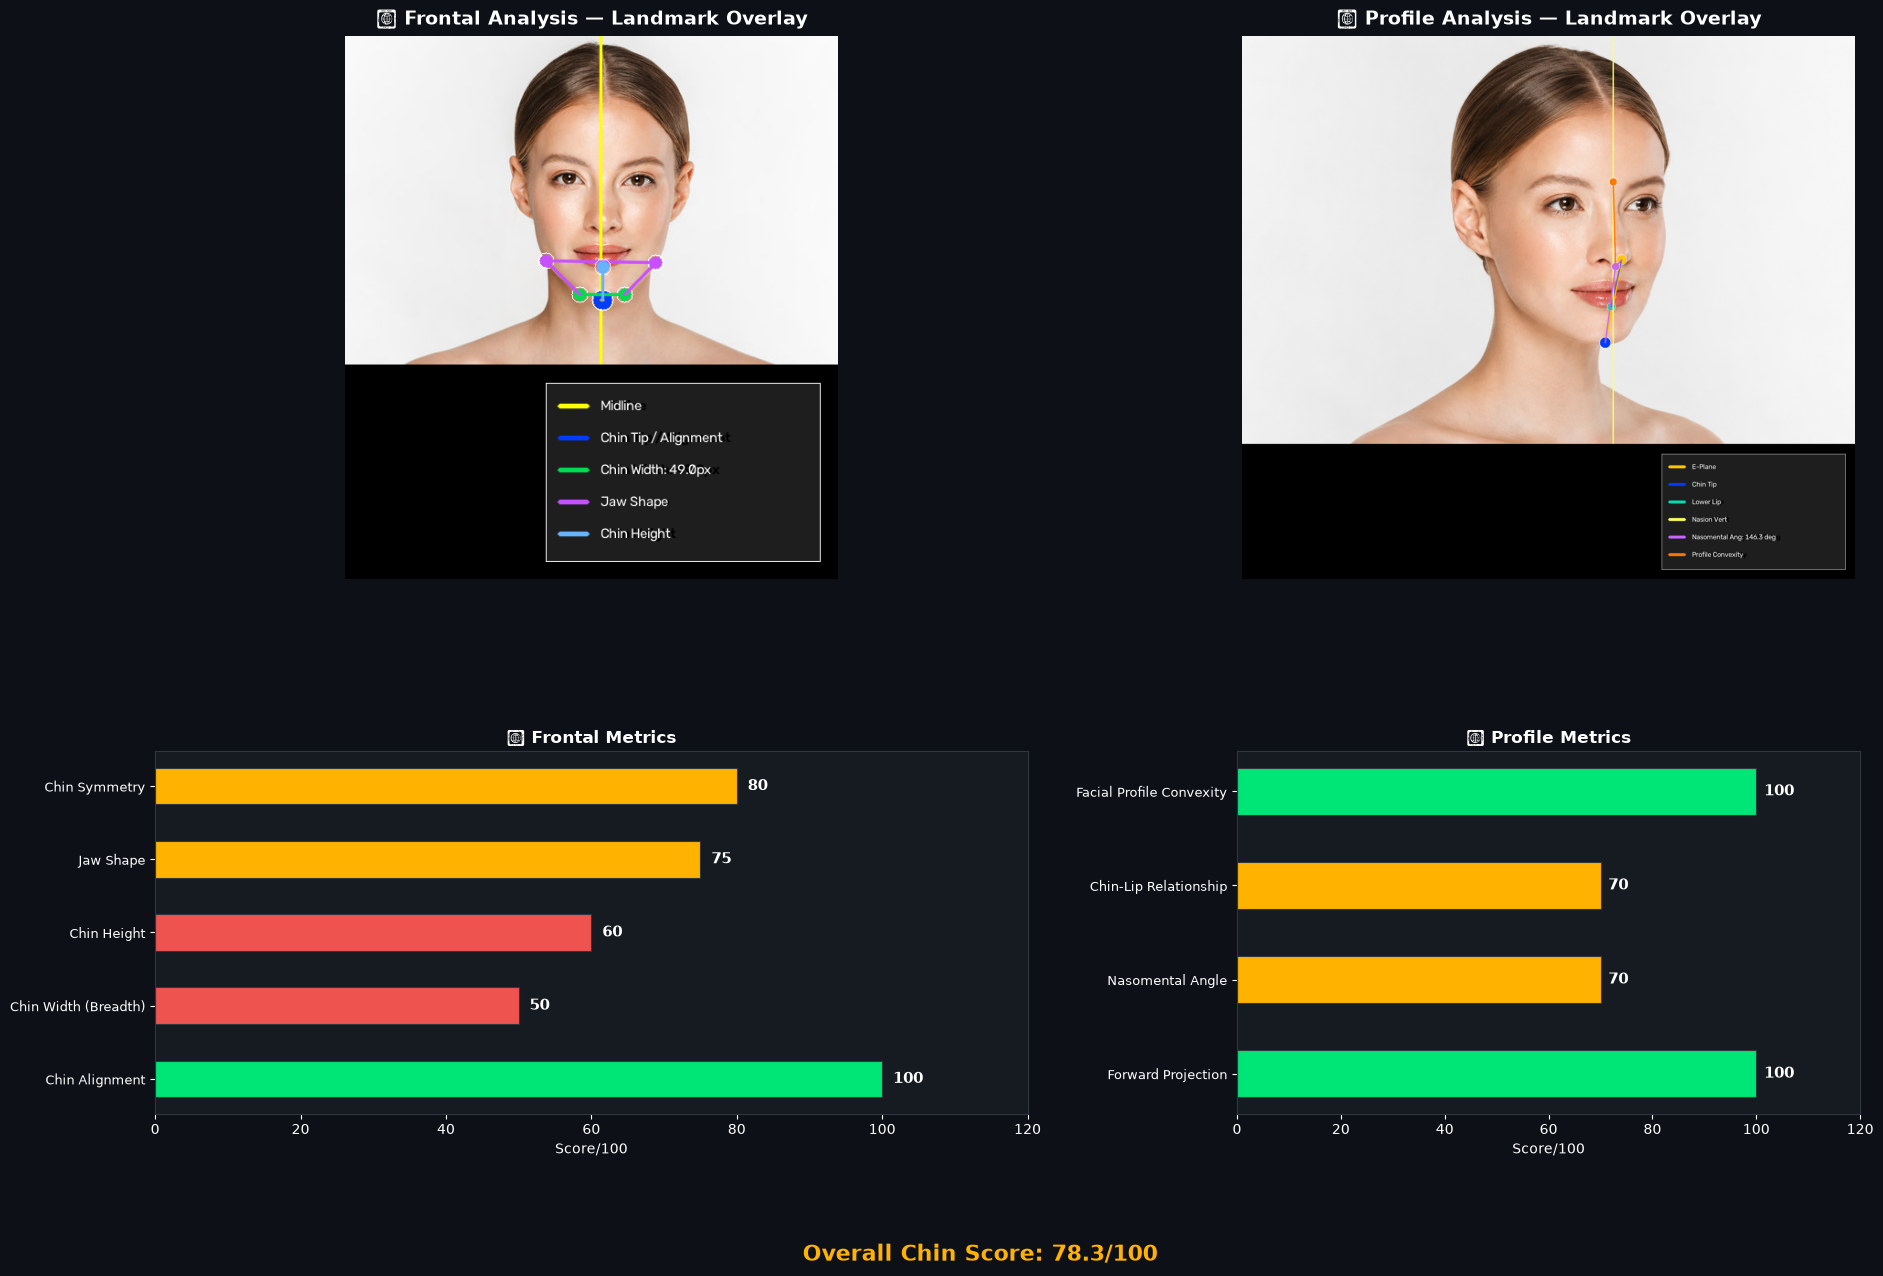

Saved: chin_analysis_dual.png


In [99]:
ann_front   = draw_frontal(rgb_f, frontal_results)
ann_profile  = draw_profile(rgb_p, profile_results)

fig = plt.figure(figsize=(22, 14), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.28, hspace=0.38,
                         width_ratios=[1.4,1], height_ratios=[1.5,1])

# ── Top-left: Annotated frontal ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(ann_front)
ax1.set_title('📸 Frontal Analysis — Landmark Overlay',
               color='white', fontsize=14, fontweight='bold', pad=8)
ax1.axis('off')

# ── Top-right: Annotated profile ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(ann_profile)
ax2.set_title('📷 Profile Analysis — Landmark Overlay',
               color='white', fontsize=14, fontweight='bold', pad=8)
ax2.axis('off')

# ── Bottom-left: Frontal score bars ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.set_facecolor('#161b22')
fm = [r['metric'] for r in frontal_results.values()]
fs = [r['score']  for r in frontal_results.values()]
fc = ['#00e676' if s>=90 else '#ffb300' if s>=65 else '#ef5350' for s in fs]
bars = ax3.barh(fm, fs, color=fc, height=0.5, edgecolor='#30363d', linewidth=0.8)
for b,s in zip(bars,fs):
    ax3.text(b.get_width()+1.5, b.get_y()+b.get_height()/2, str(s),
             va='center', color='white', fontsize=11, fontweight='bold')
ax3.set_xlim(0,120); ax3.set_xlabel('Score/100', color='white')
ax3.set_title('📸 Frontal Metrics', color='white', fontsize=12, fontweight='bold')
ax3.tick_params(colors='white'); ax3.spines[:].set_color('#30363d')
plt.setp(ax3.get_yticklabels(), color='white', fontsize=9)
plt.setp(ax3.get_xticklabels(), color='white')

# ── Bottom-right: Profile score bars ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
ax4.set_facecolor('#161b22')
pm = [r['metric'].replace(' (Profile)','') for r in profile_results.values()]
ps = [r['score'] for r in profile_results.values()]
pc = ['#00e676' if s>=90 else '#ffb300' if s>=65 else '#ef5350' for s in ps]
bars2 = ax4.barh(pm, ps, color=pc, height=0.5, edgecolor='#30363d', linewidth=0.8)
for b,s in zip(bars2,ps):
    ax4.text(b.get_width()+1.5, b.get_y()+b.get_height()/2, str(s),
             va='center', color='white', fontsize=11, fontweight='bold')
ax4.set_xlim(0,120); ax4.set_xlabel('Score/100', color='white')
ax4.set_title('📷 Profile Metrics', color='white', fontsize=12, fontweight='bold')
ax4.tick_params(colors='white'); ax4.spines[:].set_color('#30363d')
plt.setp(ax4.get_yticklabels(), color='white', fontsize=9)
plt.setp(ax4.get_xticklabels(), color='white')

# Overall score badge
all_s = fs + ps
overall = round(sum(all_s)/len(all_s), 1)
bc = '#00e676' if overall>=85 else '#ffb300' if overall>=65 else '#ef5350'
fig.text(0.5, 0.005, f'Overall Chin Score: {overall}/100',
         ha='center', fontsize=16, fontweight='bold', color=bc)

plt.savefig('chin_analysis_dual.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: chin_analysis_dual.png')

## 💾 Export Results as JSON (for API integration)

In [100]:
def to_serializable(d):
    if isinstance(d, dict): return {k: to_serializable(v) for k,v in d.items()}
    if isinstance(d, (tuple,list)): return [to_serializable(i) for i in d]
    return d

all_scores = [r['score'] for r in list(frontal_results.values())+list(profile_results.values())]
export = {
    'frontal_image' : FRONTAL_IMAGE,
    'profile_image' : PROFILE_IMAGE,
    'frontal'       : to_serializable(frontal_results),
    'profile'       : to_serializable(profile_results),
    'overall_score' : round(sum(all_scores)/len(all_scores), 1),
}

with open('chin_analysis_results.json','w') as f:
    json.dump(export, f, indent=2)

print('Saved: chin_analysis_results.json')

# Quick summary
summary = {}
for k,v in export['frontal'].items():  summary[f'frontal_{k}'] = {'result':v['result'],'score':v['score']}
for k,v in export['profile'].items():  summary[f'profile_{k}'] = {'result':v['result'],'score':v['score']}
summary['overall_score'] = export['overall_score']
print(json.dumps(summary, indent=2))

Saved: chin_analysis_results.json
{
  "frontal_alignment": {
    "result": "CENTRALLY ALIGNED",
    "score": 100
  },
  "frontal_width": {
    "result": "NARROW",
    "score": 50
  },
  "frontal_height": {
    "result": "LONG LOWER THIRD",
    "score": 60
  },
  "frontal_jaw_shape": {
    "result": "V-SHAPED JAW",
    "score": 75
  },
  "frontal_symmetry": {
    "result": "MILDLY ASYMMETRIC",
    "score": 80
  },
  "profile_forward_projection": {
    "result": "IDEAL PROJECTION",
    "score": 100
  },
  "profile_nasomental": {
    "result": "OBTUSE \u2014 RETRUDED CHIN",
    "score": 70
  },
  "profile_chin_lip": {
    "result": "LIP ANTERIOR TO CHIN (lip prominent)",
    "score": 70
  },
  "profile_convexity": {
    "result": "STRAIGHT PROFILE (ideal)",
    "score": 100
  },
  "overall_score": 78.3
}


---
## 📝 Team Notes

### Photo Guidelines
| Photo | Requirements |
|-------|-------------|
| **Frontal** | Face perfectly forward · neutral expression · eyes at same level · good lighting |
| **Side Profile** | True 90° side view · head in natural position · forehead-to-chin fully visible |

### Metrics Summary
| Photo | Metric | Key Value | Ideal Range |
|-------|--------|-----------|-------------|
| Frontal | Alignment | Deviation % | < 2% |
| Frontal | Width | Chin/Mouth ratio | 0.90–1.10 |
| Frontal | Height | Lower-third ratio | 0.28–0.38 |
| Frontal | Jaw Shape | Taper ratio | 0.60–0.80 |
| Frontal | Symmetry | Asymmetry % | < 3% |
| Profile | Forward Proj. | Proj. ratio | −0.05 to +0.08 |
| Profile | Nasomental Angle | Degrees | 120–135° |
| Profile | Chin-Lip | H-ratio | −0.02 to +0.02 |
| Profile | Convexity | Profile angle | 165–175° |

### Key Landmarks Used
```
Chin Tip (pogonion)   152    Jaw Gonion L/R  172/397
Jaw Angle L/R         136/365  Cheekbone L/R 234/454
Glabella/Nasion        9    Nose Tip (pronasale)  1
Nose Base (subnasale)  2    Lower Lip Bottom     17
Forehead              10
```

> All results are Python dicts — serializable to JSON for REST API integration.